# Triple Barrier Labeling for CL1S Oil Signals

This notebook builds triple-barrier labels for the CL1S crude oil futures signal series using training data only, with dates before `2022-01-01`. It is intentionally written as a step-by-step workflow so the labelling logic is visible before being wrapped into `run_triple_barrier_pipeline(...)` at the end.

## What happens in this notebook

1. Load raw OHLCV data and primary signals.
2. Restrict the analysis to training data before `2022-01-01`.
3. Select the CL1S oil price series and its primary signal.
4. Estimate daily volatility with several methods, using EWMA as the baseline.
5. Keep primary signals equal to `0` in the plotting timeline, but ignore them for barrier construction because they represent no active trade.
6. Build take-profit, stop-loss, and timeout barriers for each active `+1` or `-1` signal date.
7. Walk forward through each event's price path and assign a triple-barrier label.
8. Create a metalabel comparing the primary signal with the realised barrier label.
9. Visualise the barriers, labels, signal outcomes, and zoomed example scenarios.
10. Provide `run_triple_barrier_pipeline(...)` so the same process can be called later with different instruments and parameters.

## Label convention

- `triple_barrier_label = 1`: upper barrier touched first.
- `triple_barrier_label = -1`: lower barrier touched first.
- `triple_barrier_label = 0`: neither barrier touched before the timeout date.
- metalabel = 1: following the primary signal was profitable by the first barrier touch or timeout exit
- metalabel = 0: following the primary signal was unprofitable or flat by the first barrier touch or timeout exit

## Main parameters

The baseline example uses EWMA volatility with `span=100`, a 10-trading-day timeout, and symmetric `2.0x` volatility take-profit and stop-loss barrier widths. These can be changed directly in the notebook or passed into `run_triple_barrier_pipeline(...)`.


## Active-signal rule

Primary signals equal to `0` mean no active position. They stay visible in the notebook visuals so the price timeline remains complete, but they are ignored before barrier construction and are not labelled. The label `0` can still appear as `triple_barrier_label = 0`, which means an active `+1` or `-1` signal timed out before either horizontal barrier was touched.


## Training window

All notebook analysis uses dates before `2022-01-01`. The reusable pipeline has the same default cutoff through `training_end="2022-01-01"`, so CPCV/configuration tests do not accidentally use 2022 out-of-sample data.


In [1]:
# Notebook setup
# - Import numerical/data libraries.
# - Keep plotting inline.
# - The rest of the notebook defines the triple-barrier workflow directly,
#   then wraps it in a reusable function at the end.
import sys
import os
import tempfile

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

In [2]:
# Load raw market data and primary signals.
# This notebook focuses on CL1S oil, but the final pipeline function can be
# called with other instruments and signal columns.
TRAINING_END = pd.Timestamp("2022-01-01")

ohlcv = pd.read_csv('../data/raw/ohlcv_data.csv', parse_dates=['date']).set_index('date')
signals_all = pd.read_csv('../data/raw/primary_signals.csv', parse_dates=['date']).set_index('date')

# Keep this notebook analysis strictly in-sample: dates before 2022-01-01 only.
ohlcv_training = ohlcv.loc[ohlcv.index < TRAINING_END].copy()
signals_training = signals_all.loc[signals_all.index < TRAINING_END].copy()

# ── Oil-only slice ──────────────────────────────────────────────────────────
oil = ohlcv_training[ohlcv_training['instrument'] == 'cl1s'].copy()
oil = oil.sort_index()

close = oil['close']
high  = oil['high']
low   = oil['low']
open_ = oil['open']

# Primary signal for CL1S (available from Jan 2020).
# Keep the full signal series for plotting. The active-only copy is used for
# barrier labelling so 0 means visible in charts, but not labelled or traded.
signal_cl1s = signals_training['cl1s']
active_signal_cl1s = signal_cl1s[signal_cl1s.isin([-1, 1])]

print(f'Training cutoff  : dates before {TRAINING_END.date()}')
print(f'Oil price history : {close.index.min().date()} → {close.index.max().date()} ({len(close):,} days)')
print(f'Primary signal    : {signal_cl1s.index.min().date()} → {signal_cl1s.index.max().date()} ({len(signal_cl1s):,} days)')
print('\nSignal distribution:')
print(signal_cl1s.value_counts().sort_index())
print('\nActive signal distribution used for barriers:')
print(active_signal_cl1s.value_counts().sort_index())

Training cutoff  : dates before 2022-01-01
Oil price history : 1990-01-02 → 2021-12-31 (8,047 days)
Primary signal    : 2020-01-03 → 2021-12-31 (517 days)

Signal distribution:
cl1s
-1     26
 0    183
 1    308
Name: count, dtype: int64

Active signal distribution used for barriers:
cl1s
-1     26
 1    308
Name: count, dtype: int64


In [3]:
def ewma_daily_vol(close: pd.Series, span: int = 100) -> pd.Series:
    """
    - Exponentially weighted moving average of daily log-return volatility.
    - This is the estimator recommended in Lopez de Prado (2018) for calibrating
    triple-barrier widths
    - Weights recent observations more heavily, making barriers adaptive to current market regimes
    """
    log_returns = np.log(close / close.shift(1)).dropna()
    vol = log_returns.ewm(span=span, min_periods=span).std()
    return vol.reindex(close.index)


def rolling_daily_vol(close: pd.Series, window: int = 20) -> pd.Series:
    """
    - Simple rolling standard deviation of daily log returns
    - Equal-weighted (more baseline)
    """
    log_returns = np.log(close / close.shift(1))
    return log_returns.rolling(window=window, min_periods=window).std()


def parkinson_daily_vol(high: pd.Series, low: pd.Series, window: int = 20) -> pd.Series:
    """
    - Parkinson (1980) range-based volatility estimator.
    - Uses intraday high/low to estimate volatility (5x more efficinet)
    """
    log_hl = np.log(high / low)
    parkinson_sq = (log_hl ** 2) / (4 * np.log(2))
    return np.sqrt(parkinson_sq.rolling(window=window, min_periods=window).mean())


def garman_klass_daily_vol(
    open_: pd.Series,
    high: pd.Series,
    low: pd.Series,
    close: pd.Series,
    window: int = 20,
) -> pd.Series:
    """
    - Garman-Klass (1980) volatility estimator
    - Incorporates open, high, low, close for a more efficient estimate than either close-to-close or Parkinson alone.
    """
    log_hl = np.log(high / low)
    log_co = np.log(close / open_)
    gk = 0.5 * log_hl ** 2 - (2 * np.log(2) - 1) * log_co ** 2
    return np.sqrt(gk.rolling(window=window, min_periods=window).mean())


In [4]:
def create_barriers(
    close: pd.Series,
    signal: pd.Series,
    vol: pd.Series,
    num_days: int = 10,
    take_profit_mult: float = 2.0,
    stop_loss_mult: float = 2.0,
) -> pd.DataFrame:
    """
    Creates a simple triple-barrier table for one instrument.

    Uses active signals only: -1 and +1. Signal 0 means no trade and is dropped before barriers are built.

    Timeout is num_days trading observations later using the close price index.
    """

    close = close.sort_index()
    signal = signal.sort_index()
    vol = vol.sort_index()

    # Align close, signal, and volatility
    df = pd.DataFrame({
        "close": close,
        "primary_signal": signal,
        "vol": vol,
    })

    df = df.dropna(subset=["close", "primary_signal", "vol"]).copy()
    df["primary_signal"] = df["primary_signal"].astype(int)

    # Only label active trade signals. A primary signal of 0 means no position.
    df = df[df["primary_signal"].isin([-1, 1])].copy()

    # Use the full close price index to calculate timeout dates
    price_series = close.dropna().sort_index()
    price_index = price_series.index

    # Find where each event date sits in the full oil price history
    event_positions = price_index.get_indexer(df.index)

    # Timeout is num_days trading rows later
    timeout_positions = event_positions + num_days

    # Keep only rows where timeout date exists
    valid_timeout = (event_positions >= 0) & (timeout_positions < len(price_index))

    df = df.loc[valid_timeout].copy()
    timeout_positions = timeout_positions[valid_timeout]

    # Add timeout date and timeout close
    df["timeout_date"] = price_index[timeout_positions]
    df["timeout_close"] = price_series.iloc[timeout_positions].values

    # Directional barrier side: +1 for long signals, -1 for short signals.
    barrier_side = df["primary_signal"]

    df["tp"] = df["close"] * (1 + barrier_side * take_profit_mult * df["vol"])
    df["sl"] = df["close"] * (1 - barrier_side * stop_loss_mult * df["vol"])

    df = df.reset_index().rename(columns={"index": "date"})

    return df[
        [
            "date",
            "close",
            "primary_signal",
            "vol",
            "tp",
            "sl",
            "timeout_date",
            "timeout_close",
        ]
    ]

In [5]:
vol = ewma_daily_vol(close, span=100)

barriers = create_barriers(
    close=close,
    signal=active_signal_cl1s,
    vol=vol,
    num_days=10,
    take_profit_mult=2.0,
    stop_loss_mult=2.0,
)

barriers.head()

,date,close,primary_signal,vol,tp,sl,timeout_date,timeout_close
0,2020-01-07,25.411618,-1,0.019602,24.415356,26.407881,2020-01-22,22.984255
1,2020-01-22,22.984255,-1,0.019635,22.081640,23.886869,2020-02-05,20.557824
2,2020-01-23,22.518412,-1,0.019641,21.633829,23.402995,2020-02-06,20.638840
3,2020-01-24,21.951300,-1,0.019750,21.084219,22.818381,2020-02-07,20.383639
4,2020-01-27,21.525966,-1,0.019720,20.677001,22.374930,2020-02-10,20.079829


In [ ]:
def apply_triple_barrier_labels(
    barriers: pd.DataFrame,
    close: pd.Series,
) -> pd.DataFrame:
    """
    Apply triple-barrier outcomes and binary metalabels.

    triple_barrier_label:
        1  = upper barrier touched first
       -1  = lower barrier touched first
        0  = neither horizontal barrier touched before timeout

    metalabel:
        1 = following the primary signal made money by the touch/timeout date
        0 = following the primary signal lost money or broke even

    This means timeout rows are not automatically failures.
    They are labelled using the signed return at timeout.
    """

    close = close.dropna().sort_index()
    labelled = barriers.copy()

    triple_barrier_labels = []
    touch_dates = []
    touch_prices = []
    touched_barriers = []

    for _, row in labelled.iterrows():
        start_date = row["date"]
        timeout_date = row["timeout_date"]

        upper_barrier = max(row["tp"], row["sl"])
        lower_barrier = min(row["tp"], row["sl"])

        price_path = close.loc[
            (close.index > start_date)
            & (close.index <= timeout_date)
        ]

        # Default case: timeout
        label = 0
        touch_date = timeout_date
        touch_price = row["timeout_close"]
        touched_barrier = "timeout"

        for current_date, current_close in price_path.items():
            if current_close >= upper_barrier:
                label = 1
                touch_date = current_date
                touch_price = current_close
                touched_barrier = "upper"
                break

            if current_close <= lower_barrier:
                label = -1
                touch_date = current_date
                touch_price = current_close
                touched_barrier = "lower"
                break

        triple_barrier_labels.append(label)
        touch_dates.append(touch_date)
        touch_prices.append(touch_price)
        touched_barriers.append(touched_barrier)

    labelled["triple_barrier_label"] = triple_barrier_labels
    labelled["touch_date"] = touch_dates
    labelled["touch_price"] = touch_prices
    labelled["touched_barrier"] = touched_barriers

    # Return from entry to touch/timeout
    labelled["raw_touch_return"] = (
        labelled["touch_price"] / labelled["close"]
    ) - 1

    # Return from the perspective of following the primary signal
    labelled["signed_touch_return"] = (
        labelled["raw_touch_return"] * labelled["primary_signal"]
    )

    # Final binary meta-label:
    # 1 if following the primary signal was profitable,
    # 0 if it was not profitable or exactly flat.
    labelled["metalabel"] = (
        labelled["signed_touch_return"] > 0
    ).astype(int)

    return labelled

In [7]:
# %%
barriers_labelled = apply_triple_barrier_labels(
    barriers=barriers,
    close=close,
)

assert not barriers_labelled["primary_signal"].eq(0).any(), "Primary signal 0 rows should be dropped before labelling."

# Build a separate plotting table that preserves the full close/signal timeline.
# Only active +/-1 dates have barrier outputs; primary_signal == 0 rows remain
# visible in the charts with missing labels instead of being labelled.
visualisation_df = (
    pd.DataFrame({
        "date": close.index,
        "close": close.values,
        "primary_signal": signal_cl1s.reindex(close.index).values,
    })
    .merge(
        barriers_labelled.drop(columns=["close", "primary_signal"], errors="ignore"),
        on="date",
        how="left",
    )
)

barriers_labelled[
    ["date", "primary_signal", "triple_barrier_label", "metalabel"]
]

barriers_labelled.head()

df = barriers_labelled

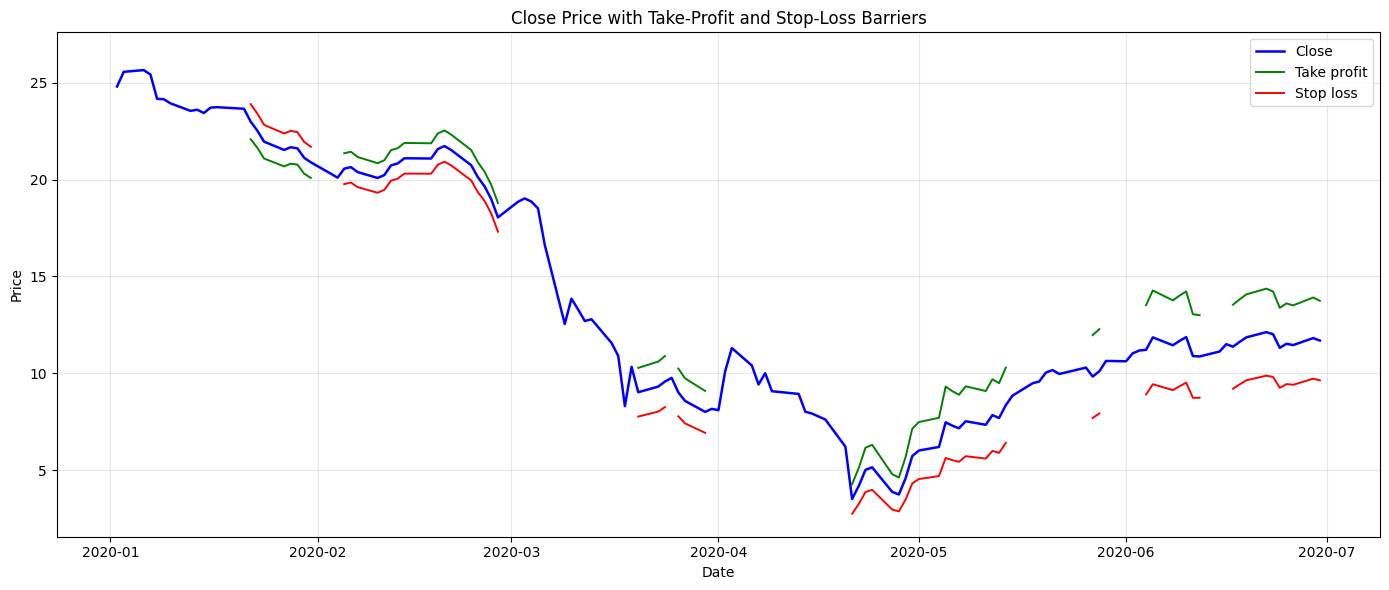

In [8]:
def plot_full_barrier_series(
    labelled: pd.DataFrame,
    start_date: str | None = None,
    end_date: str | None = None,
):
    """
    Plots the full time series of:
    - close price
    - take-profit barrier
    - stop-loss barrier

    This shows how the barriers change over time for every event/date.
    """

    df = labelled.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date")

    if start_date is not None:
        df = df[df["date"] >= pd.to_datetime(start_date)]

    if end_date is not None:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    plt.figure(figsize=(14, 6))

    plt.plot(
        df["date"],
        df["close"],
        color="blue",
        linewidth=1.8,
        label="Close"
    )

    plt.plot(
        df["date"],
        df["tp"],
        color="green",
        linewidth=1.4,
        label="Take profit"
    )

    plt.plot(
        df["date"],
        df["sl"],
        color="red",
        linewidth=1.4,
        label="Stop loss"
    )

    plt.title("Close Price with Take-Profit and Stop-Loss Barriers")
    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_full_barrier_series(visualisation_df, start_date="2020-01-01", end_date="2020-06-30")

In [9]:
mode="primary_line"    # primary signal controls line colour, metalabel controls background
mode="metalabel_line"  # metalabel controls line colour, primary signal controls background

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_close_with_primary_and_metalabel(
    labelled: pd.DataFrame,
    mode: str = "primary_line",
    start_date: str | None = None,
    end_date: str | None = None,
):
    """
    Plot close price with colours based on primary_signal and metalabel.

    Modes:
    - mode="primary_line":
        line colour       = primary_signal
        background colour = metalabel

    - mode="metalabel_line":
        line colour       = metalabel
        background colour = primary_signal
    """

    df = labelled.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    if start_date is not None:
        df = df[df["date"] >= pd.to_datetime(start_date)]

    if end_date is not None:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    df = df.reset_index(drop=True)

    if mode not in ["primary_line", "metalabel_line"]:
        raise ValueError("mode must be either 'primary_line' or 'metalabel_line'.")

    primary_colours = {
        1: "green",
        0: "blue",
        -1: "red",
    }

    metalabel_colours = {
        1.0: "green",
        0.0: "red",
    }

    def get_primary_colour(value):
        if pd.isna(value):
            return "lightgrey"
        return primary_colours.get(int(value), "grey")

    def get_metalabel_colour(value):
        if pd.isna(value):
            return "lightgrey"
        return metalabel_colours.get(float(value), "grey")

    plt.figure(figsize=(15, 6))

    for i in range(len(df) - 1):

        if mode == "primary_line":
            line_colour = get_primary_colour(df.loc[i, "primary_signal"])
            background_colour = get_metalabel_colour(df.loc[i, "metalabel"])

        elif mode == "metalabel_line":
            line_colour = get_metalabel_colour(df.loc[i, "metalabel"])
            background_colour = get_primary_colour(df.loc[i, "primary_signal"])

        # Background shading
        plt.axvspan(
            df.loc[i, "date"],
            df.loc[i + 1, "date"],
            color=background_colour,
            alpha=0.08,
        )

        # Close price line
        plt.plot(
            [df.loc[i, "date"], df.loc[i + 1, "date"]],
            [df.loc[i, "close"], df.loc[i + 1, "close"]],
            color=line_colour,
            linewidth=2,
        )

    primary_legend = [
        Line2D([0], [0], color="green", linewidth=2, label="Primary signal +1"),
        Line2D([0], [0], color="blue", linewidth=2, label="Primary signal 0"),
        Line2D([0], [0], color="red", linewidth=2, label="Primary signal -1"),
    ]

    metalabel_legend = [
        Line2D([0], [0], color="green", linewidth=2, label="Metalabel 1"),
        Line2D([0], [0], color="red", linewidth=2, label="Metalabel 0"),
        Line2D([0], [0], color="lightgrey", linewidth=2, label="No barrier event"),
    ]

    primary_background_legend = [
        Patch(facecolor="green", alpha=0.08, label="Primary signal +1 background"),
        Patch(facecolor="blue", alpha=0.08, label="Primary signal 0 background"),
        Patch(facecolor="red", alpha=0.08, label="Primary signal -1 background"),
    ]

    metalabel_background_legend = [
        Patch(facecolor="green", alpha=0.08, label="Metalabel 1 background"),
        Patch(facecolor="red", alpha=0.08, label="Metalabel 0 background"),
        Patch(facecolor="lightgrey", alpha=0.08, label="No barrier event background"),
    ]

    if mode == "primary_line":
        legend_handles = primary_legend + metalabel_background_legend
        title = "Close Price: Primary Signal Line Colour with Metalabel Background"

    else:
        legend_handles = metalabel_legend + primary_background_legend
        title = "Close Price: Metalabel Line Colour with Primary Signal Background"

    plt.legend(handles=legend_handles, loc="best")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

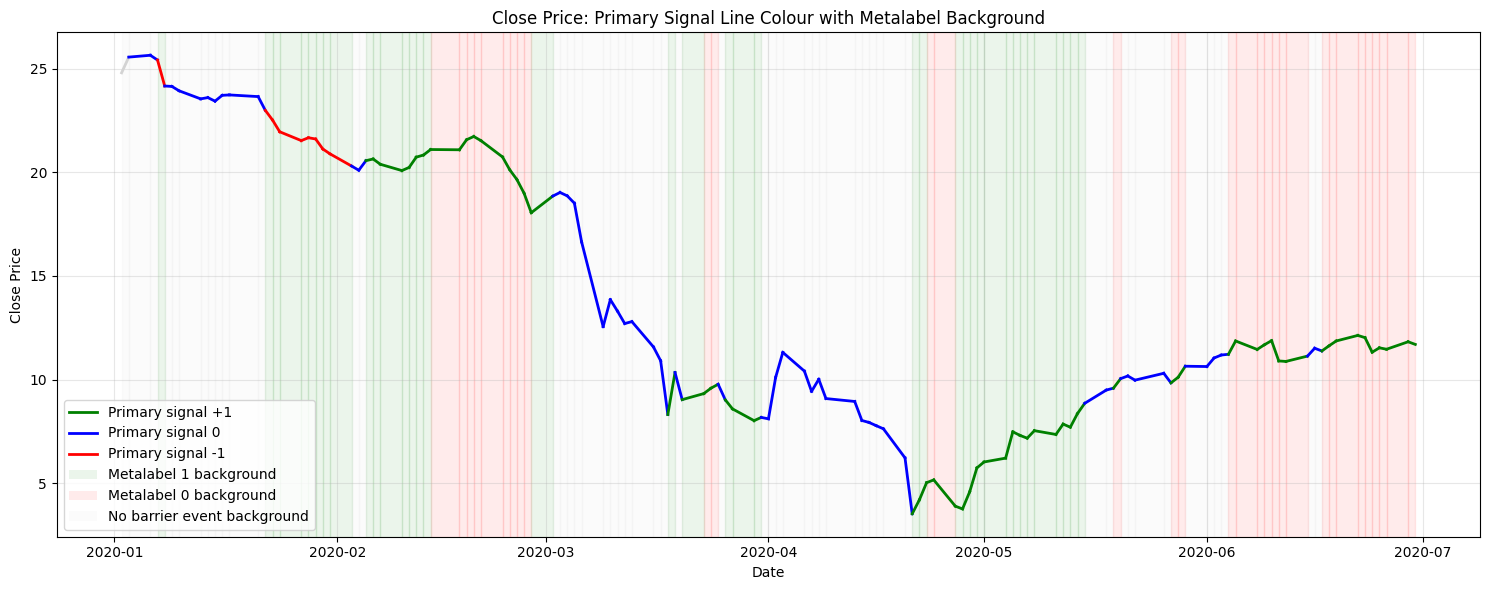

In [10]:
plot_close_with_primary_and_metalabel(
    labelled=visualisation_df,
    mode="primary_line",
    start_date="2020-01-01",
    end_date="2020-06-30",
)

In [11]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_close_with_tb_and_signal(
    labelled: pd.DataFrame,
    mode: str = "tb_line",
    start_date: str | None = None,
    end_date: str | None = None,
):
    """
    Plots close price with primary signal and triple barrier label.

    Modes:
    - mode="tb_line":
        line colour       = triple_barrier_label
        background colour = primary_signal

    - mode="signal_line":
        line colour       = primary_signal
        background colour = triple_barrier_label
    """

    df = labelled.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    if start_date is not None:
        df = df[df["date"] >= pd.to_datetime(start_date)]

    if end_date is not None:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    df = df.reset_index(drop=True)

    if mode not in ["tb_line", "signal_line"]:
        raise ValueError("mode must be either 'tb_line' or 'signal_line'.")

    colours = {
        1: "green",
        0: "blue",
        -1: "red",
    }

    def get_colour(value):
        if pd.isna(value):
            return "lightgrey"
        return colours[int(value)]

    plt.figure(figsize=(15, 6))

    for i in range(len(df) - 1):

        if mode == "tb_line":
            line_value = df.loc[i, "triple_barrier_label"]
            background_value = df.loc[i, "primary_signal"]

        elif mode == "signal_line":
            line_value = df.loc[i, "primary_signal"]
            background_value = df.loc[i, "triple_barrier_label"]

        # Background shading
        plt.axvspan(
            df.loc[i, "date"],
            df.loc[i + 1, "date"],
            color=get_colour(background_value),
            alpha=0.08,
        )

        # Close price line
        plt.plot(
            [df.loc[i, "date"], df.loc[i + 1, "date"]],
            [df.loc[i, "close"], df.loc[i + 1, "close"]],
            color=get_colour(line_value),
            linewidth=2,
        )

    tb_legend = [
        Line2D([0], [0], color="green", linewidth=2, label="TB label +1"),
        Line2D([0], [0], color="blue", linewidth=2, label="TB label 0"),
        Line2D([0], [0], color="red", linewidth=2, label="TB label -1"),
        Line2D([0], [0], color="lightgrey", linewidth=2, label="No barrier event"),
    ]

    signal_legend = [
        Line2D([0], [0], color="green", linewidth=2, label="Primary signal +1"),
        Line2D([0], [0], color="blue", linewidth=2, label="Primary signal 0"),
        Line2D([0], [0], color="red", linewidth=2, label="Primary signal -1"),
    ]

    tb_background_legend = [
        Patch(facecolor="green", alpha=0.08, label="TB label +1 background"),
        Patch(facecolor="blue", alpha=0.08, label="TB label 0 background"),
        Patch(facecolor="red", alpha=0.08, label="TB label -1 background"),
        Patch(facecolor="lightgrey", alpha=0.08, label="No barrier event background"),
    ]

    signal_background_legend = [
        Patch(facecolor="green", alpha=0.08, label="Primary signal +1 background"),
        Patch(facecolor="blue", alpha=0.08, label="Primary signal 0 background"),
        Patch(facecolor="red", alpha=0.08, label="Primary signal -1 background"),
    ]

    if mode == "tb_line":
        legend_handles = tb_legend + signal_background_legend
        title = "Close Price: Triple Barrier Line Colour with Primary Signal Shading"

    else:
        legend_handles = signal_legend + tb_background_legend
        title = "Close Price: Primary Signal Line Colour with Triple Barrier Shading"

    plt.legend(handles=legend_handles, loc="best")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

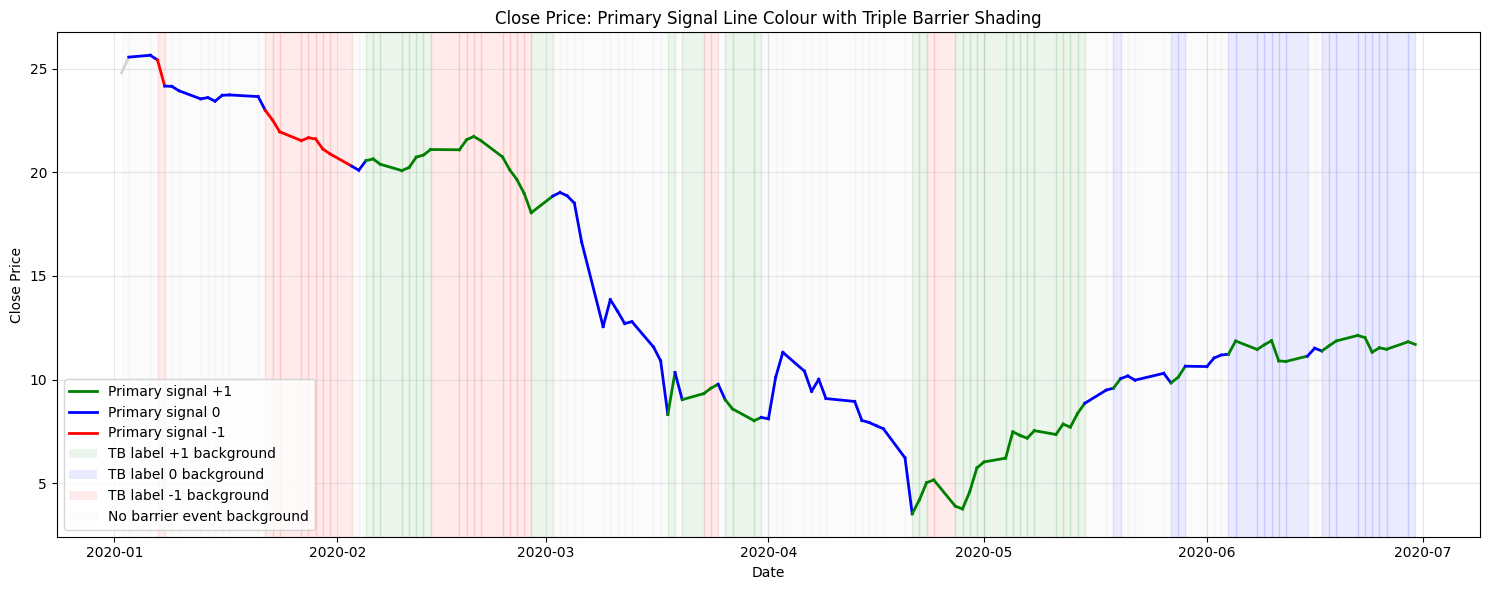

In [12]:
plot_close_with_tb_and_signal(
    labelled=visualisation_df,
    mode="signal_line",
    start_date="2020-01-01",
    end_date="2020-06-30",
)

In [13]:
print("Triple barrier label counts:")
print(barriers_labelled["triple_barrier_label"].value_counts().sort_index())

print("\nMetalabel counts:")
print(barriers_labelled["metalabel"].value_counts().sort_index())

Triple barrier label counts:
triple_barrier_label
-1     87
 0    115
 1    122
Name: count, dtype: int64

Metalabel counts:
metalabel
0    201
1    123
Name: count, dtype: int64


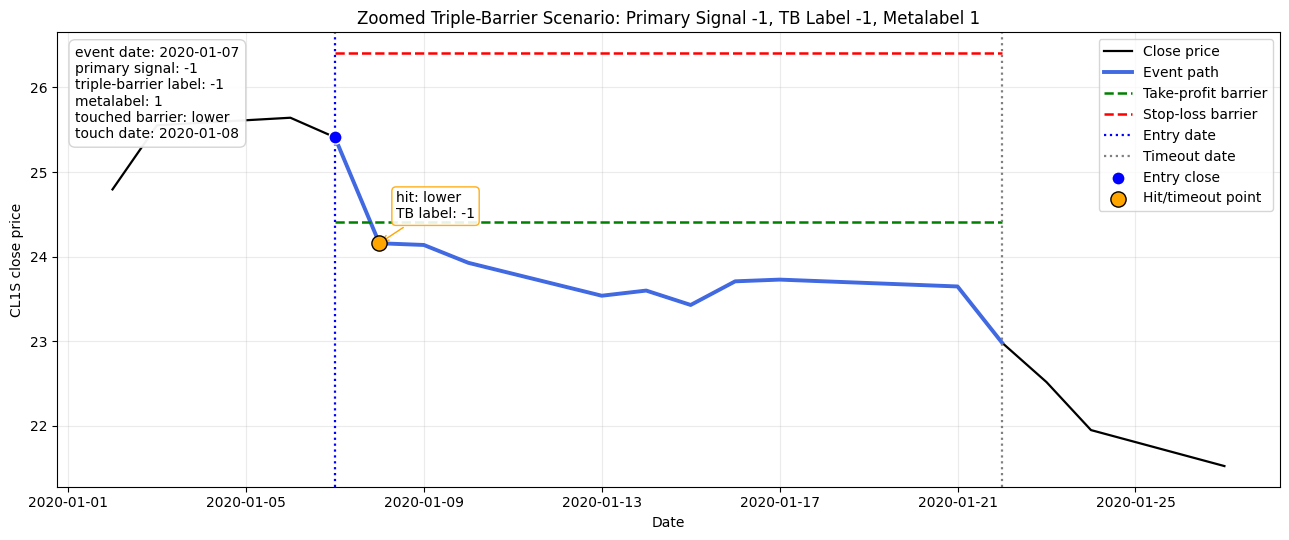

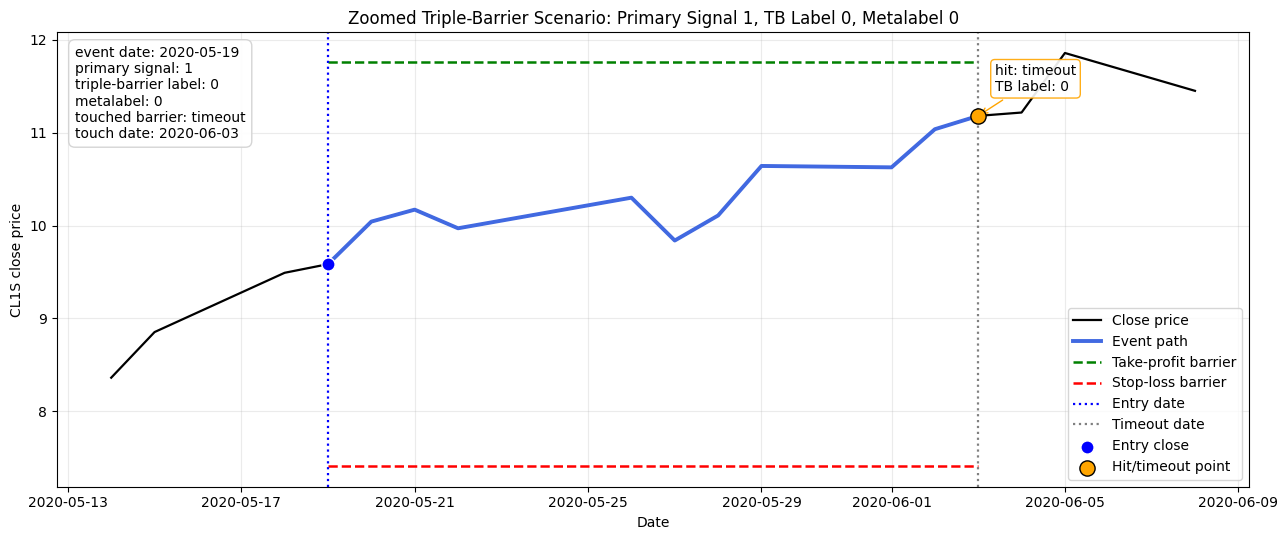

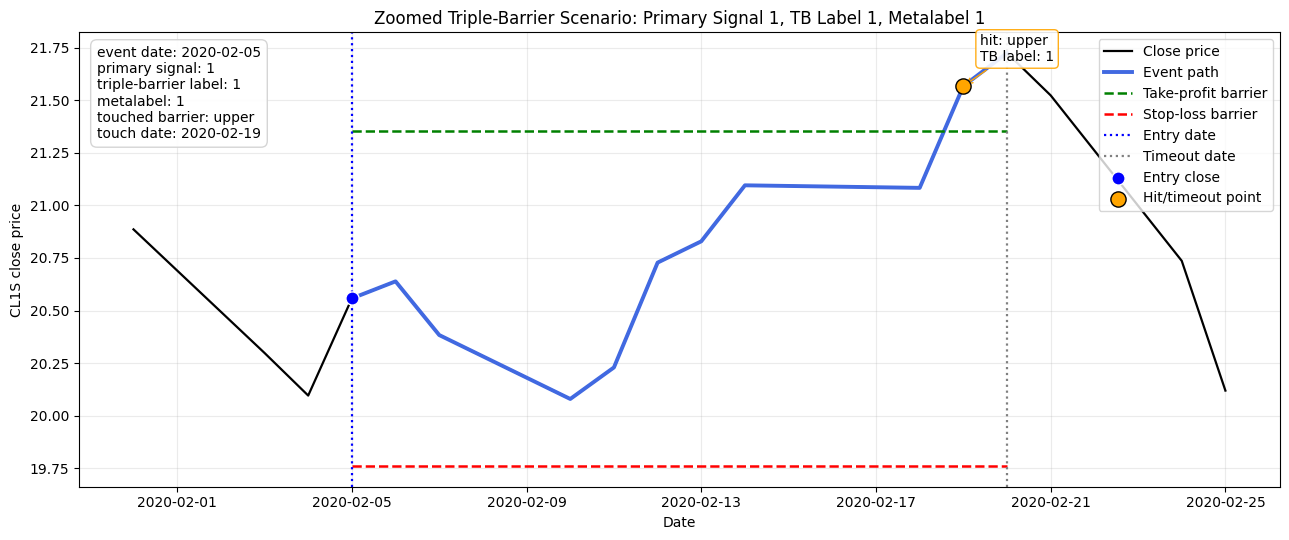

,date,primary_signal,tp,sl,timeout_date,touch_date,touch_price,touched_barrier,triple_barrier_label,metalabel
0,2020-01-07,-1,24.415356,26.407881,2020-01-22,2020-01-08,24.159275,lower,-1,1
1,2020-05-19,1,11.759198,7.407625,2020-06-03,2020-06-03,11.181646,timeout,0,0
2,2020-02-05,1,21.354767,19.760881,2020-02-20,2020-02-19,21.567081,upper,1,1


In [14]:
def select_triple_barrier_examples(
    labelled: pd.DataFrame,
    labels: tuple[int, ...] = (-1, 0, 1),
    examples_per_label: int = 1,
) -> pd.DataFrame:
    """
    Pick a small set of labelled events for zoomed visual inspection.

    The examples come from active +/-1 primary-signal rows only. Primary-signal
    0 rows are still visible in the earlier full-timeline plots, but they do not
    have barriers or labels and are therefore not selected here.
    """

    examples = []
    ordered = labelled.sort_values("date").reset_index(drop=True)

    for label in labels:
        label_rows = ordered[ordered["triple_barrier_label"] == label]
        if label_rows.empty:
            continue

        if len(label_rows) <= examples_per_label:
            examples.append(label_rows)
        else:
            # Spread examples through time rather than taking only the earliest rows.
            sample_positions = np.linspace(
                0,
                len(label_rows) - 1,
                examples_per_label,
                dtype=int,
            )
            examples.append(label_rows.iloc[sample_positions])

    if not examples:
        return pd.DataFrame(columns=ordered.columns)

    return pd.concat(examples, ignore_index=True)


def plot_triple_barrier_event(
    event: pd.Series,
    close: pd.Series,
    padding_observations: int = 3,
):
    """
    Plot one zoomed-in triple-barrier scenario.

    The chart shows the entry date, close-price path, directional take-profit and
    stop-loss barriers, timeout date, actual touch/timeout point, primary signal,
    triple-barrier label, and metalabel.
    """

    price = close.dropna().sort_index()

    start_date = pd.to_datetime(event["date"])
    timeout_date = pd.to_datetime(event["timeout_date"])
    touch_date = pd.to_datetime(event["touch_date"])

    start_pos = price.index.searchsorted(start_date)
    timeout_pos = price.index.searchsorted(timeout_date)
    left_pos = max(0, start_pos - padding_observations)
    right_pos = min(len(price) - 1, timeout_pos + padding_observations)

    zoom = price.iloc[left_pos : right_pos + 1]
    event_path = price.loc[(price.index >= start_date) & (price.index <= timeout_date)]

    primary_signal = int(event["primary_signal"])
    tb_label = int(event["triple_barrier_label"])
    metalabel = int(event["metalabel"])
    touched_barrier = str(event["touched_barrier"])

    fig, ax = plt.subplots(figsize=(13, 5.5))

    ax.plot(
        zoom.index,
        zoom.values,
        color="black",
        linewidth=1.6,
        label="Close price",
    )
    ax.plot(
        event_path.index,
        event_path.values,
        color="royalblue",
        linewidth=2.8,
        label="Event path",
    )

    ax.hlines(
        event["tp"],
        xmin=start_date,
        xmax=timeout_date,
        color="green",
        linestyle="--",
        linewidth=1.8,
        label="Take-profit barrier",
    )
    ax.hlines(
        event["sl"],
        xmin=start_date,
        xmax=timeout_date,
        color="red",
        linestyle="--",
        linewidth=1.8,
        label="Stop-loss barrier",
    )

    ax.axvline(start_date, color="blue", linestyle=":", linewidth=1.6, label="Entry date")
    ax.axvline(timeout_date, color="grey", linestyle=":", linewidth=1.6, label="Timeout date")

    ax.scatter(
        [start_date],
        [event["close"]],
        color="blue",
        edgecolor="white",
        s=90,
        zorder=5,
        label="Entry close",
    )
    ax.scatter(
        [touch_date],
        [event["touch_price"]],
        color="orange",
        edgecolor="black",
        s=120,
        zorder=6,
        label="Hit/timeout point",
    )

    ax.annotate(
        f"hit: {touched_barrier}\nTB label: {tb_label}",
        xy=(touch_date, event["touch_price"]),
        xytext=(12, 18),
        textcoords="offset points",
        arrowprops={"arrowstyle": "->", "color": "orange"},
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "orange", "alpha": 0.9},
    )

    scenario_text = (
        f"event date: {start_date.date()}\n"
        f"primary signal: {primary_signal}\n"
        f"triple-barrier label: {tb_label}\n"
        f"metalabel: {metalabel}\n"
        f"touched barrier: {touched_barrier}\n"
        f"touch date: {touch_date.date()}"
    )
    ax.text(
        0.015,
        0.97,
        scenario_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "edgecolor": "lightgrey", "alpha": 0.95},
    )

    ax.set_title(
        "Zoomed Triple-Barrier Scenario: "
        f"Primary Signal {primary_signal}, TB Label {tb_label}, Metalabel {metalabel}"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("CL1S close price")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def plot_triple_barrier_examples(
    labelled: pd.DataFrame,
    close: pd.Series,
    labels: tuple[int, ...] = (-1, 0, 1),
    examples_per_label: int = 1,
    padding_observations: int = 3,
) -> pd.DataFrame:
    """
    Show zoomed diagrams for representative triple-barrier scenarios.

    Returns the example rows so the dates and labels can be inspected directly
    after the charts.
    """

    examples = select_triple_barrier_examples(
        labelled=labelled,
        labels=labels,
        examples_per_label=examples_per_label,
    )

    if examples.empty:
        print("No matching triple-barrier examples found.")
        return examples

    for _, event in examples.iterrows():
        plot_triple_barrier_event(
            event=event,
            close=close,
            padding_observations=padding_observations,
        )

    return examples[
        [
            "date",
            "primary_signal",
            "tp",
            "sl",
            "timeout_date",
            "touch_date",
            "touch_price",
            "touched_barrier",
            "triple_barrier_label",
            "metalabel",
        ]
    ]


example_scenarios = plot_triple_barrier_examples(
    labelled=barriers_labelled,
    close=close,
    labels=(-1, 0, 1),
    examples_per_label=1,
    padding_observations=3,
)

example_scenarios

In [15]:
def run_triple_barrier_pipeline(
    instrument: str = "cl1s",
    ohlcv_path: str = "../data/raw/ohlcv_data.csv",
    signals_path: str = "../data/raw/primary_signals.csv",
    signal_column: str | None = None,
    training_end: str | pd.Timestamp | None = "2022-01-01",
    volatility_method: str = "ewma",
    ewma_span: int = 100,
    volatility_window: int = 20,
    num_days: int = 10,
    take_profit_mult: float = 2.0,
    stop_loss_mult: float = 2.0,
    output_path: str | None = None,
    save_columns: list[str] | None = None,
) -> pd.DataFrame:
    """
    Run the full triple-barrier labelling workflow for one instrument.

    The function is designed for repeated CPCV / hyperparameter tests:
    - training_end defaults to "2022-01-01", using dates strictly before that cutoff
    - primary_signal == 0 rows are ignored before labelling
    - the returned dataframe contains active labelled trades only
    - each row includes the barrier configuration used to create it
    - CSV output is optional, so parameter sweeps can run without writing files

    Parameters
    ----------
    instrument:
        Instrument code in the OHLCV file, for example "cl1s".
    ohlcv_path:
        Path to the raw OHLCV CSV.
    signals_path:
        Path to the primary-signals CSV.
    signal_column:
        Primary-signal column to use. Defaults to the same value as instrument.
    training_end:
        Exclusive training cutoff. Dates on or after this value are not used.
        Use None only if you intentionally want to use the full dataset.
    volatility_method:
        One of "ewma", "rolling", "parkinson", "garman_klass", "garman-klass", or "gk".
    ewma_span:
        Span used when volatility_method="ewma".
    volatility_window:
        Window used by rolling, Parkinson, and Garman-Klass volatility estimators.
    num_days:
        Vertical barrier length in trading observations.
    take_profit_mult:
        Take-profit barrier width as a multiple of volatility.
    stop_loss_mult:
        Stop-loss barrier width as a multiple of volatility.
    output_path:
        Optional CSV path. If None, nothing is saved.
    save_columns:
        Optional subset of columns to save when output_path is provided.

    Returns
    -------
    pd.DataFrame
        Active-signal labelled dataframe with barrier levels, touch details,
        labels, configuration metadata, and derived return/holding-period fields.
    """

    from pathlib import Path

    signal_column = instrument if signal_column is None else signal_column

    ohlcv_data = pd.read_csv(ohlcv_path, parse_dates=["date"]).set_index("date")
    signals_data = pd.read_csv(signals_path, parse_dates=["date"]).set_index("date")

    training_end_timestamp = None if training_end is None else pd.Timestamp(training_end)
    if training_end_timestamp is not None:
        ohlcv_data = ohlcv_data.loc[ohlcv_data.index < training_end_timestamp].copy()
        signals_data = signals_data.loc[signals_data.index < training_end_timestamp].copy()

    instrument_data = ohlcv_data[ohlcv_data["instrument"] == instrument].sort_index().copy()
    if instrument_data.empty:
        raise ValueError(
            f"No OHLCV rows found for instrument={instrument!r} before training_end={training_end!r}"
        )
    if signal_column not in signals_data.columns:
        raise ValueError(f"Signal column {signal_column!r} not found in {signals_path}")

    close_series = instrument_data["close"]
    high_series = instrument_data["high"]
    low_series = instrument_data["low"]
    open_series = instrument_data["open"]
    signal_series = signals_data[signal_column]

    # Active trades only. A zero primary signal means no position and is not labelled.
    active_signal_series = signal_series[signal_series.isin([-1, 1])]

    volatility_method_key = volatility_method.lower().replace("-", "_")
    if volatility_method_key == "ewma":
        vol_series = ewma_daily_vol(close_series, span=ewma_span)
        volatility_method_label = "ewma"
    elif volatility_method_key == "rolling":
        vol_series = rolling_daily_vol(close_series, window=volatility_window)
        volatility_method_label = "rolling"
    elif volatility_method_key == "parkinson":
        vol_series = parkinson_daily_vol(high_series, low_series, window=volatility_window)
        volatility_method_label = "parkinson"
    elif volatility_method_key in {"garman_klass", "gk"}:
        vol_series = garman_klass_daily_vol(
            open_=open_series,
            high=high_series,
            low=low_series,
            close=close_series,
            window=volatility_window,
        )
        volatility_method_label = "garman_klass"
    else:
        raise ValueError(
            "volatility_method must be one of 'ewma', 'rolling', 'parkinson', "
            "'garman_klass', 'garman-klass', or 'gk'"
        )

    barrier_table = create_barriers(
        close=close_series,
        signal=active_signal_series,
        vol=vol_series,
        num_days=num_days,
        take_profit_mult=take_profit_mult,
        stop_loss_mult=stop_loss_mult,
    )

    labelled = apply_triple_barrier_labels(
        barriers=barrier_table,
        close=close_series,
    )

    labelled.insert(0, "instrument", instrument)
    labelled.insert(1, "signal_column", signal_column)
    labelled["training_end"] = training_end_timestamp
    labelled["volatility_method"] = volatility_method_label
    labelled["ewma_span"] = ewma_span
    labelled["volatility_window"] = volatility_window
    labelled["num_days"] = num_days
    labelled["take_profit_mult"] = take_profit_mult
    labelled["stop_loss_mult"] = stop_loss_mult

    labelled["holding_period_days"] = (
        pd.to_datetime(labelled["touch_date"]) - pd.to_datetime(labelled["date"])
    ).dt.days
    labelled["raw_touch_return"] = (labelled["touch_price"] / labelled["close"]) - 1
    labelled["signed_touch_return"] = labelled["raw_touch_return"] * labelled["primary_signal"]

    output_columns = [
        "instrument",
        "signal_column",
        "training_end",
        "date",
        "close",
        "primary_signal",
        "vol",
        "tp",
        "sl",
        "timeout_date",
        "timeout_close",
        "touch_date",
        "touch_price",
        "touched_barrier",
        "triple_barrier_label",
        "metalabel",
        "volatility_method",
        "ewma_span",
        "volatility_window",
        "num_days",
        "take_profit_mult",
        "stop_loss_mult",
        "holding_period_days",
        "raw_touch_return",
        "signed_touch_return",
    ]
    labelled = labelled[output_columns]

    if output_path is not None:
        columns_to_save = output_columns if save_columns is None else save_columns
        missing_columns = sorted(set(columns_to_save) - set(labelled.columns))
        if missing_columns:
            raise ValueError(f"save_columns contains columns not in output: {missing_columns}")

        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        labelled[columns_to_save].to_csv(output_path, index=False)

    return labelled

In [ ]:
# Test the default pipeline output before moving the logic into a .py module.
default_tb_output = run_triple_barrier_pipeline()

# Check timeout rows are now labelled by signed return
timeout_rows = default_tb_output[
    default_tb_output["touched_barrier"] == "timeout"
].copy()

if not timeout_rows.empty:
    check = (
        timeout_rows["metalabel"]
        == (timeout_rows["signed_touch_return"] > 0).astype(int)
    )

    assert check.all(), "Timeout metalabels are not aligned with signed return."

    print("Timeout metalabel check passed.")
    print(timeout_rows[[
        "date",
        "primary_signal",
        "close",
        "timeout_close",
        "raw_touch_return",
        "signed_touch_return",
        "metalabel",
    ]].head())
else:
    print("No timeout rows found for this config.")

print("Default triple-barrier output shape:", default_tb_output.shape)
print("\nColumns:")
print(default_tb_output.columns.tolist())

print("\nTriple-barrier label counts:")
print(default_tb_output["triple_barrier_label"].value_counts().sort_index())

print("\nMetalabel counts:")
print(default_tb_output["metalabel"].value_counts().sort_index())

important_columns = [
    "instrument",
    "training_end",
    "date",
    "close",
    "primary_signal",
    "vol",
    "tp",
    "sl",
    "timeout_date",
    "touch_date",
    "touch_price",
    "touched_barrier",
    "triple_barrier_label",
    "metalabel",
    "holding_period_days",
    "raw_touch_return",
    "signed_touch_return",
]

print("\nMissing values in important columns:")
print(default_tb_output[important_columns].isna().sum())

assert not default_tb_output["primary_signal"].eq(0).any(), "Pipeline output should be active signals only."
assert not default_tb_output["date"].duplicated().any(), "CL1S output should not duplicate event dates."
assert default_tb_output["date"].max() < TRAINING_END, "Event dates should be before the training cutoff."
assert default_tb_output["timeout_date"].max() < TRAINING_END, "Timeout dates should be before the training cutoff."
assert default_tb_output["touch_date"].max() < TRAINING_END, "Touch dates should be before the training cutoff."

default_tb_output.head()

Default triple-barrier output shape: (324, 25)

Columns:
['instrument', 'signal_column', 'training_end', 'date', 'close', 'primary_signal', 'vol', 'tp', 'sl', 'timeout_date', 'timeout_close', 'touch_date', 'touch_price', 'touched_barrier', 'triple_barrier_label', 'metalabel', 'volatility_method', 'ewma_span', 'volatility_window', 'num_days', 'take_profit_mult', 'stop_loss_mult', 'holding_period_days', 'raw_touch_return', 'signed_touch_return']

Triple-barrier label counts:
triple_barrier_label
-1     87
 0    115
 1    122
Name: count, dtype: int64

Metalabel counts:
metalabel
0    201
1    123
Name: count, dtype: int64

Missing values in important columns:
instrument              0
training_end            0
date                    0
close                   0
primary_signal          0
vol                     0
tp                      0
sl                      0
timeout_date            0
touch_date              0
touch_price             0
touched_barrier         0
triple_barrier_label  

,instrument,signal_column,training_end,date,close,primary_signal,vol,tp,sl,timeout_date,...,metalabel,volatility_method,ewma_span,volatility_window,num_days,take_profit_mult,stop_loss_mult,holding_period_days,raw_touch_return,signed_touch_return
0,cl1s,cl1s,2022-01-01,2020-01-07,25.411618,-1,0.019602,24.415356,26.407881,2020-01-22,...,1,ewma,100,20,10,2.0,2.0,1,-0.049282,0.049282
1,cl1s,cl1s,2022-01-01,2020-01-22,22.984255,-1,0.019635,22.081640,23.886869,2020-02-05,...,1,ewma,100,20,10,2.0,2.0,2,-0.044942,0.044942
2,cl1s,cl1s,2022-01-01,2020-01-23,22.518412,-1,0.019641,21.633829,23.402995,2020-02-06,...,1,ewma,100,20,10,2.0,2.0,4,-0.044073,0.044073
3,cl1s,cl1s,2022-01-01,2020-01-24,21.951300,-1,0.019750,21.084219,22.818381,2020-02-07,...,1,ewma,100,20,10,2.0,2.0,7,-0.048533,0.048533
4,cl1s,cl1s,2022-01-01,2020-01-27,21.525966,-1,0.019720,20.677001,22.374930,2020-02-10,...,1,ewma,100,20,10,2.0,2.0,7,-0.057019,0.057019


In [17]:
# Compare several CPCV-style triple-barrier configurations.
# This does not save files; it returns dataframes so later CPCV code can decide what to keep.
comparison_configs = [
    {
        "config_name": "ewma_default",
        "volatility_method": "ewma",
        "ewma_span": 100,
        "volatility_window": 20,
        "num_days": 10,
        "take_profit_mult": 2.0,
        "stop_loss_mult": 2.0,
    },
    {
        "config_name": "rolling_vol",
        "volatility_method": "rolling",
        "ewma_span": 100,
        "volatility_window": 20,
        "num_days": 10,
        "take_profit_mult": 2.0,
        "stop_loss_mult": 2.0,
    },
    {
        "config_name": "parkinson_vol",
        "volatility_method": "parkinson",
        "ewma_span": 100,
        "volatility_window": 20,
        "num_days": 10,
        "take_profit_mult": 2.0,
        "stop_loss_mult": 2.0,
    }
]

comparison_rows = []
comparison_outputs = {}

for config in comparison_configs:
    config_name = config["config_name"]
    kwargs = {k: v for k, v in config.items() if k != "config_name"}
    labelled_config = run_triple_barrier_pipeline(**kwargs)
    comparison_outputs[config_name] = labelled_config

    label_counts = labelled_config["triple_barrier_label"].value_counts().to_dict()
    comparison_rows.append({
        **config,
        "n_labelled_rows": len(labelled_config),
        "label_-1_count": label_counts.get(-1, 0),
        "label_0_count": label_counts.get(0, 0),
        "label_1_count": label_counts.get(1, 0),
        "metalabel_success_rate": labelled_config["metalabel"].mean(),
        "avg_holding_period_days": labelled_config["holding_period_days"].mean(),
        "avg_signed_touch_return": labelled_config["signed_touch_return"].mean(),
    })

comparison_summary = pd.DataFrame(comparison_rows)
comparison_summary

,config_name,volatility_method,ewma_span,volatility_window,num_days,take_profit_mult,stop_loss_mult,n_labelled_rows,label_-1_count,label_0_count,label_1_count,metalabel_success_rate,avg_holding_period_days,avg_signed_touch_return
0,ewma_default,ewma,100,20,10,2.0,2.0,324,87,115,122,0.379630,10.182099,0.025366
1,rolling_vol,rolling,100,20,10,2.0,2.0,324,98,77,149,0.466049,8.648148,0.036627
2,parkinson_vol,parkinson,100,20,10,2.0,2.0,324,93,87,144,0.441358,9.182099,0.036863


In [18]:
# Small behaviour checks for saving and validation.
with tempfile.TemporaryDirectory() as tmpdir:
    test_output_path = os.path.join(tmpdir, "tb_test_output.csv")
    saved_output = run_triple_barrier_pipeline(output_path=test_output_path)
    saved_csv = pd.read_csv(test_output_path)

    assert saved_csv.shape == saved_output.shape
    assert list(saved_csv.columns) == list(saved_output.columns)

supported_method_checks = ["ewma", "rolling", "parkinson", "garman_klass", "garman-klass", "gk"]
for method in supported_method_checks:
    method_output = run_triple_barrier_pipeline(volatility_method=method)
    assert not method_output.empty, f"{method} should return labelled rows"
    assert method_output["timeout_date"].max() < TRAINING_END, f"{method} should not use post-cutoff timeout dates"

try:
    run_triple_barrier_pipeline(volatility_method="not_a_method")
except ValueError as exc:
    print("Invalid volatility method check passed:", exc)
else:
    raise AssertionError("Invalid volatility method should raise ValueError")

try:
    run_triple_barrier_pipeline(
        output_path=os.path.join(tempfile.gettempdir(), "tb_bad_columns_test.csv"),
        save_columns=["date", "not_a_real_column"],
    )
except ValueError as exc:
    print("Bad save_columns check passed:", exc)
else:
    raise AssertionError("Bad save_columns should raise ValueError")

print("Supported volatility method checks passed:", supported_method_checks)
print("Saving and validation checks passed.")

Invalid volatility method check passed: volatility_method must be one of 'ewma', 'rolling', 'parkinson', 'garman_klass', 'garman-klass', or 'gk'
Bad save_columns check passed: save_columns contains columns not in output: ['not_a_real_column']
Supported volatility method checks passed: ['ewma', 'rolling', 'parkinson', 'garman_klass', 'garman-klass', 'gk']
Saving and validation checks passed.
